In [144]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [166]:
df = pd.read_csv("Online Retail - Online Retail.csv")

In [167]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom


In [170]:
df.shape

(541909, 8)

In [172]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [174]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [176]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [178]:
# STEP-1: Remove missing CustomerID
before = len(df)
df = df.dropna(subset=['CustomerID'])
after = len(df)
print(f"Removed missing CustomerID: {before - after} row removed")
print(f"Remaining Rows: {len(df)}")

Removed missing CustomerID: 135080 row removed
Remaining Rows: 406829


In [180]:
# STEP-2: Remove Cancelled orders
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
after = len(df)
print(f" Removed Cancellations: {before - after} rows removed")
print(f" Remaining Rows: {len(df)}")

 Removed Cancellations: 8905 rows removed
 Remaining Rows: 397924


In [182]:
# STEP-3: Remove Negative/Zero Quantity
before = len(df)
df = df[df['Quantity'] > 0]
after = len(df)
print(f"Removed bad Quantities: {before-after} rows removed")
print(f"Remaining Rows: {len(df)}")

Removed bad Quantities: 0 rows removed
Remaining Rows: 397924


In [184]:
# STEP-4: Remove Negative/Zero unitPrice
before = len(df)
df= df[df['UnitPrice'] > 0]
after = len(df)
print(f"Removed bad UnitPrice: {before-after} rows removed")
print(f"Remaining Rows: {len(df)}")

Removed bad UnitPrice: 40 rows removed
Remaining Rows: 397884


In [190]:
# STEP-5: Fix InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"InvoiceDate fixed: {df['InvoiceDate'].dtype}")

InvoiceDate fixed: datetime64[ns]


In [194]:
# STEP-6: Fix the CustomerID type
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
print(f"CustomerID fixed: sample-- {df['CustomerID'].iloc[0]}")

CustomerID fixed: sample-- 17850


In [196]:
# STEP-7: Create TotalPrice Column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"TotalPrice Column Created")

TotalPrice Column Created


In [208]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08


In [212]:
# Confirm date range of your data
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

# Confirm unique customers remaining
print("Unique customers:", df['CustomerID'].nunique())

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4338


RFM FEATURE ENGINEERING

In [236]:
import pandas as pd
import numpy as np

# We use the day AFTER the last invoice in the dataset

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [240]:
# BUILD RFM TABLE
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()
print("\n RFM Table created!")


 RFM Table created!


In [242]:
rfm.shape

(4338, 4)

In [244]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [249]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

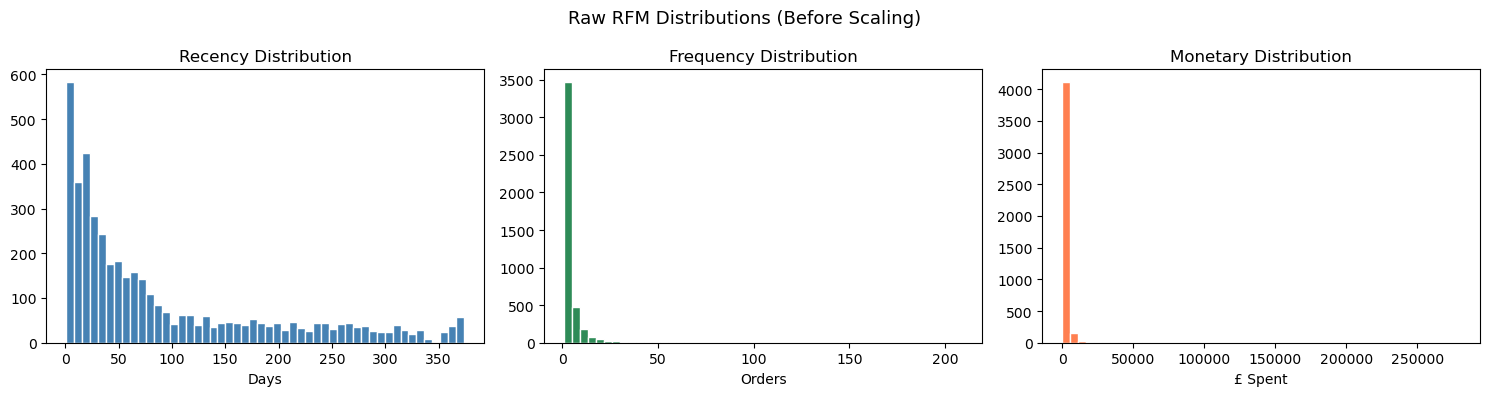

In [251]:
# VISUALIZE RAW RFM DISTRIBUTION

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'],   bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Orders')

axes[2].hist(rfm['Monetary'],  bins=50, color='coral', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('£ Spent')

plt.suptitle('Raw RFM Distributions (Before Scaling)', fontsize=13)
plt.tight_layout()
plt.show()

LOG TRANSFORMATION

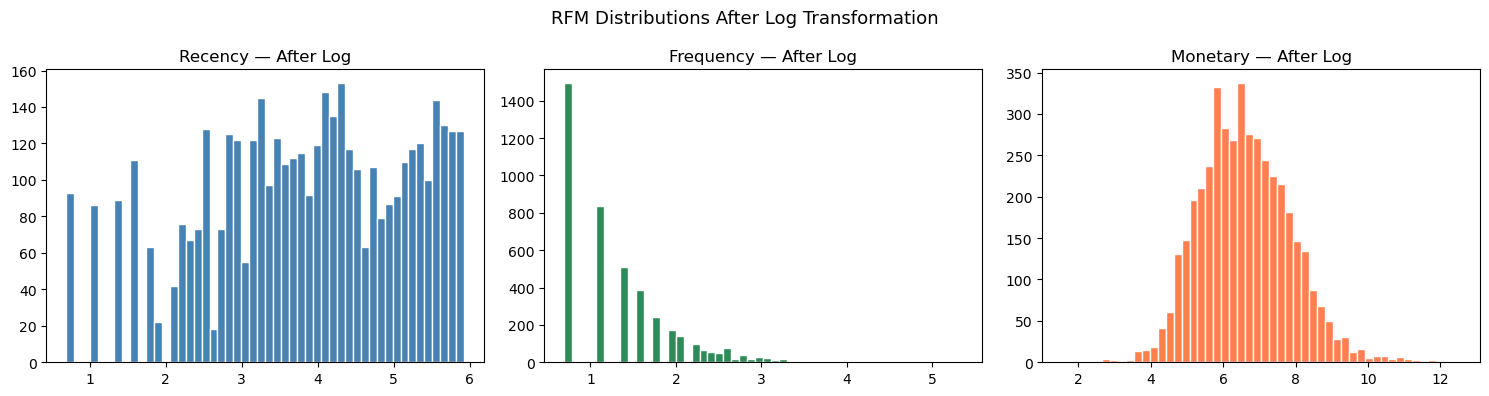

In [256]:
# Log squishes extreme values down so they don't dominate

rfm_log = rfm.copy()

rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

# Visualize after log transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm_log['Recency'],   bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency — After Log')

axes[1].hist(rfm_log['Frequency'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency — After Log')

axes[2].hist(rfm_log['Monetary'],  bins=50, color='coral', edgecolor='white')
axes[2].set_title('Monetary — After Log')

plt.suptitle('RFM Distributions After Log Transformation', fontsize=13)
plt.tight_layout()
plt.show()

In [271]:
rfm_log[['Recency','Frequency','Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,3.83,1.35,6.59
std,1.34,0.68,1.26
min,0.69,0.69,1.56
25%,2.94,0.69,5.73
50%,3.95,1.10,6.52
75%,4.96,1.79,7.42
max,5.93,5.35,12.54


MIN-MAX SCALING (bring to 0-1 range)

In [267]:
# After log, now scale everything to same range
scaler = MinMaxScaler()

rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

# Convert back to dataframe for easy reading
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

print("Scaling complete!")
print("\nScaled RFM preview (all values now between 0 and 1):")
print(rfm_scaled.head(10).round(4))

Scaling complete!

Scaled RFM preview (all values now between 0 and 1):
   Recency  Frequency  Monetary
0   0.9738     0.0000    0.8826
1   0.0775     0.2979    0.6200
2   0.6950     0.1969    0.5404
3   0.4399     0.0000    0.5384
4   0.9642     0.0000    0.3875
5   0.5575     0.3232    0.5707
6   0.8846     0.0000    0.2678
7   0.9091     0.0000    0.4940
8   0.8937     0.0000    0.4164
9   0.4748     0.1489    0.5811


In [269]:
rfm_scaled.describe().round(4)

,Recency,Frequency,Monetary
count,4338.0000,4338.0000,4338.0000
mean,0.5995,0.1402,0.4584
std,0.2561,0.1468,0.1145
min,0.0000,0.0000,0.0000
25%,0.4301,0.0000,0.3799
50%,0.6225,0.0871,0.4513
75%,0.8158,0.2361,0.5333
max,1.0000,1.0000,1.0000


In [277]:
rfm_scaled.shape

(4338, 3)

In [279]:
rfm_scaled.isnull().sum().sum()

0

In [281]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [283]:
# ELBOW METHOD
# Run K-Means for k = 2 to 10 and record inertia
# Inertia = how tight the clusters are (lower = better)

inertia = []
silhouette_scores = []
k_range = range(2, 11)

print("Testing different values of k...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"  k={k}  |  Inertia: {kmeans.inertia_:.2f}  |  Silhouette: {score:.4f}")

print("Done testing all k values!")

Testing different values of k...
  k=2  |  Inertia: 200.54  |  Silhouette: 0.4496
  k=3  |  Inertia: 140.95  |  Silhouette: 0.3699
  k=4  |  Inertia: 114.43  |  Silhouette: 0.3638
  k=5  |  Inertia: 92.42  |  Silhouette: 0.3584
  k=6  |  Inertia: 78.27  |  Silhouette: 0.3580
  k=7  |  Inertia: 68.45  |  Silhouette: 0.3477
  k=8  |  Inertia: 61.79  |  Silhouette: 0.3329
  k=9  |  Inertia: 56.72  |  Silhouette: 0.3245
  k=10  |  Inertia: 52.26  |  Silhouette: 0.3179
Done testing all k values!


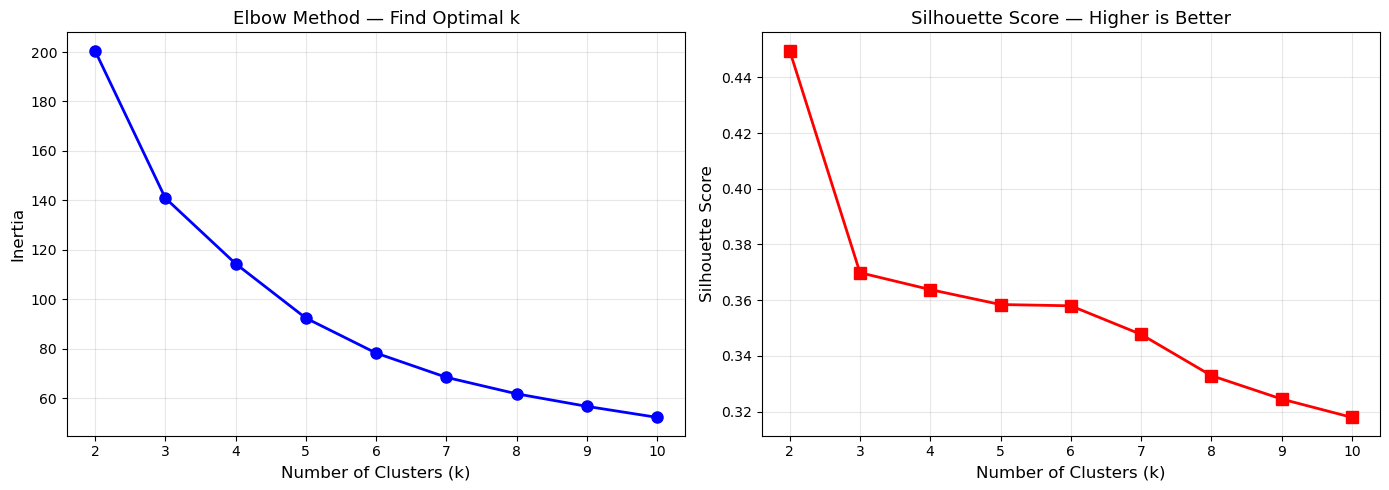

In [285]:
# PLOT ELBOW CURVE 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method — Find Optimal k', fontsize=13)
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Silhouette score curve
axes[1].plot(k_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score — Higher is Better', fontsize=13)
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [287]:
# Print best k by silhouette
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n Best k by Silhouette Score: {best_k}")
print(f"   Silhouette Score at k={best_k}: {max(silhouette_scores):.4f}")


 Best k by Silhouette Score: 2
   Silhouette Score at k=2: 0.4496


In [295]:
# ── FORCE k=4 FOR BUSINESS USEFULNESS ─────────────────
# k=2 is statistically optimal but not business-useful
# k=4 gives meaningful segments for marketing action
# Silhouette of 0.36 at k=4 is still acceptable

FINAL_K = 4

kmeans_final = KMeans(
    n_clusters = FINAL_K,
    random_state = 42,
    n_init = 10,
    max_iter = 300
)

kmeans_final.fit(rfm_scaled)
rfm['Cluster'] = kmeans_final.labels_

print(f" Final K-Means complete with k={FINAL_K}")
print(f"\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

 Final K-Means complete with k=4

Customers per cluster:
Cluster
0    1438
1     956
2    1177
3     767
Name: count, dtype: int64


In [293]:
# ── DETAILED CLUSTER ANALYSIS ─────────────────────────

cluster_summary = rfm.groupby('Cluster').agg(
    Total_Customers = ('CustomerID',  'count'),
    Avg_Recency     = ('Recency',     'mean'),
    Avg_Frequency   = ('Frequency',   'mean'),
    Avg_Monetary    = ('Monetary',    'mean'),
    Min_Recency     = ('Recency',     'min'),
    Max_Recency     = ('Recency',     'max'),
    Min_Monetary    = ('Monetary',    'min'),
    Max_Monetary    = ('Monetary',    'max')
).round(2)

print("\n" + "="*70)
print("              DETAILED CLUSTER ANALYSIS (k=4)")
print("="*70)
print(cluster_summary)
print("="*70)


              DETAILED CLUSTER ANALYSIS (k=4)
         Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Cluster                                                              
0                   1438       213.04           1.62        603.86   
1                    956        44.12           6.17       2855.57   
2                   1177        41.18           1.66        491.21   
3                    767         5.77          10.90       6173.39   

         Min_Recency  Max_Recency  Min_Monetary  Max_Monetary  
Cluster                                                        
0                 81          374          3.75      77183.60  
1                 13          372        306.72     124914.53  
2                  4           84          6.20       6207.67  
3                  1           17        124.20     280206.02  


In [325]:
# ASSIGN BUSINESS LABELS

def assign_segment(row):
    r = row['Avg_Recency']
    f = row['Avg_Frequency']
    m = row['Avg_Monetary']

    if r < 30 and f >= 5:
        return ' Champions'
    elif r < 60 and m >= 1500:
        return ' Loyal Customers'
    elif r < 90 and f <= 2:
        return 'New / Promising'
    elif r >= 90 and r < 200:
        return 'At-Risk'
    else:
        return ' Dormant'

cluster_summary['Segment'] = cluster_summary.apply(assign_segment, axis=1)


# Pct of total customers
cluster_summary['Pct_Customers'] = (
    cluster_summary['Total_Customers'] /
    cluster_summary['Total_Customers'].sum() * 100
).round(1)


In [327]:
print(cluster_summary[[
    'Segment', 'Total_Customers', 'Pct_Customers',
    'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary'
]])

                  Segment  Total_Customers  Pct_Customers  Avg_Recency  \
Cluster                                                                  
0                 Dormant             1438           33.1       213.04   
1         Loyal Customers              956           22.0        44.12   
2         New / Promising             1177           27.1        41.18   
3               Champions              767           17.7         5.77   

         Avg_Frequency  Avg_Monetary  
Cluster                               
0                 1.62        603.86  
1                 6.17       2855.57  
2                 1.66        491.21  
3                10.90       6173.39  


In [329]:
# VISUALIZATION 1: CLUSTER SCATTER PLOTS

import matplotlib.pyplot as plt
import seaborn as sns

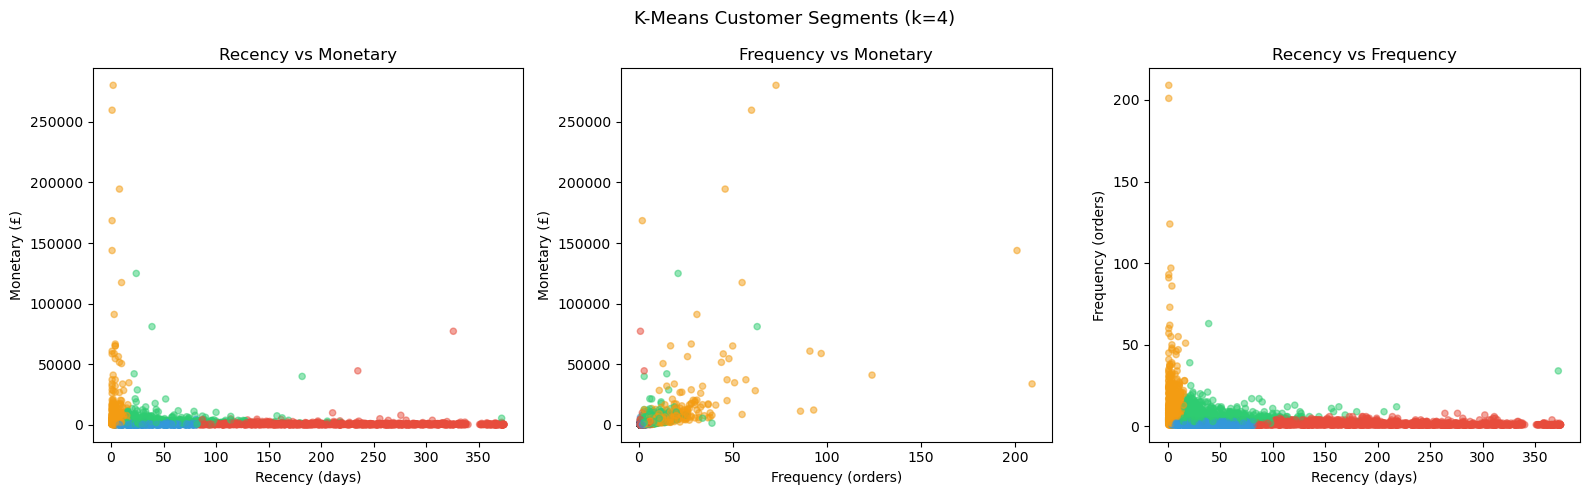

In [331]:
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
segment_colors = [colors[i] for i in rfm['Cluster']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(rfm['Recency'],   rfm['Monetary'],
                c=segment_colors, alpha=0.5, s=20)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary')

axes[1].scatter(rfm['Frequency'], rfm['Monetary'],
                c=segment_colors, alpha=0.5, s=20)
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary')

axes[2].scatter(rfm['Recency'],   rfm['Frequency'],
                c=segment_colors, alpha=0.5, s=20)
axes[2].set_xlabel('Recency (days)')
axes[2].set_ylabel('Frequency (orders)')
axes[2].set_title('Recency vs Frequency')

plt.suptitle('K-Means Customer Segments (k=4)', fontsize=13)
plt.tight_layout()
plt.show()

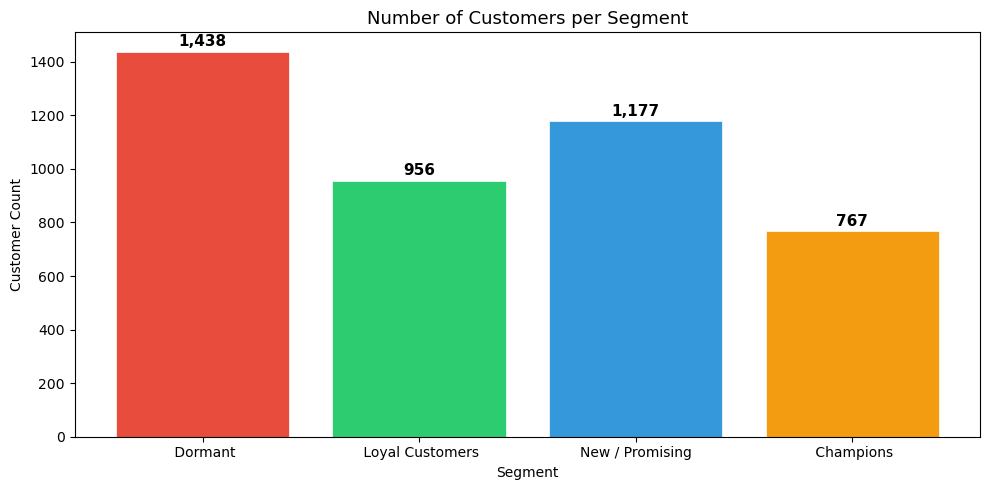

In [333]:
# VISUALIZATION 2: SEGMENT SIZE BAR CHART 

seg_counts = rfm.groupby('Cluster').size().reset_index(name='Count')
seg_counts = seg_counts.merge(
    cluster_summary[['Segment']].reset_index(), on='Cluster'
)

plt.figure(figsize=(10, 5))
bars = plt.bar(seg_counts['Segment'], seg_counts['Count'],
               color=colors[:FINAL_K], edgecolor='white', linewidth=0.5)

for bar, count in zip(bars, seg_counts['Count']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             f'{count:,}', ha='center', fontsize=11, fontweight='bold')

plt.title('Number of Customers per Segment', fontsize=13)
plt.ylabel('Customer Count')
plt.xlabel('Segment')
plt.tight_layout()
plt.show()

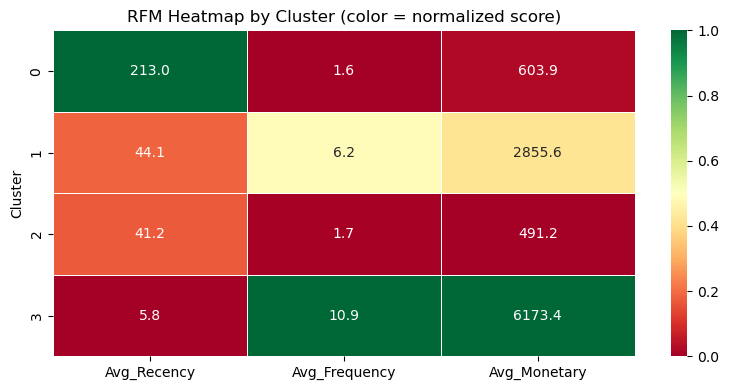

In [335]:
# VISUALIZATION 3: RFM HEATMAP PER CLUSTER 

heatmap_data = cluster_summary[
    ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
].copy()

# Normalize for heatmap display
heatmap_norm = (heatmap_data - heatmap_data.min()) / \
               (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(8, 4))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data,       # show original values
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar=True
)
plt.title('RFM Heatmap by Cluster (color = normalized score)', fontsize=12)
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

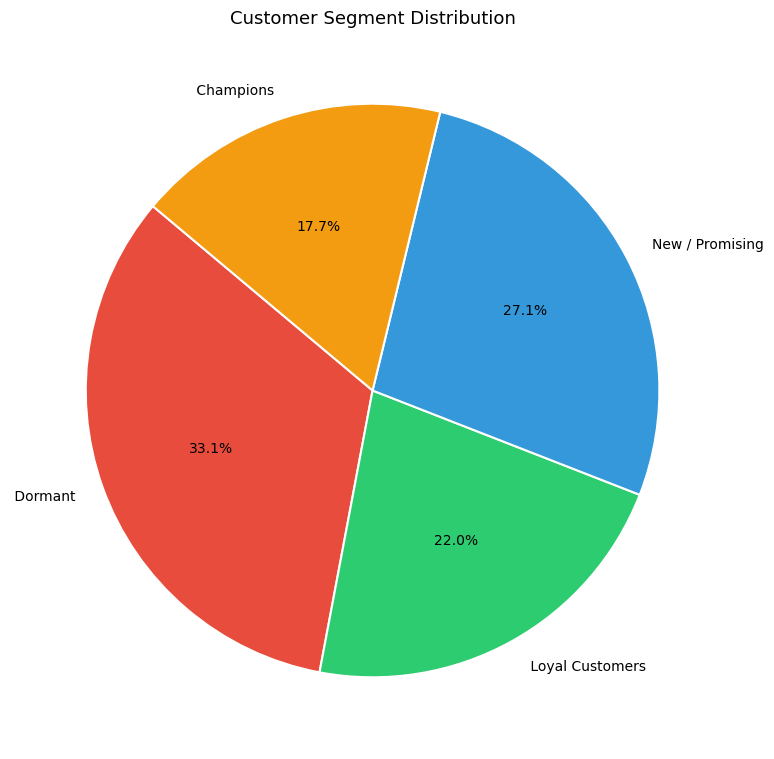

In [337]:
# VISUALIZATION 4: CUSTOMER DISTRIBUTION PIE

labels = cluster_summary['Segment'].values
sizes  = cluster_summary['Total_Customers'].values

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors[:FINAL_K],
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Customer Segment Distribution', fontsize=13)
plt.tight_layout()
plt.show()

In [339]:
# Add segment name to each customer row
rfm = rfm.merge(
    cluster_summary[['Segment']].reset_index(),
    on='Cluster'
)

In [341]:
# Save to CSV
rfm.to_csv('customer_segments.csv', index=False)

In [343]:
len(rfm)

4338

In [347]:
rfm.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment'], dtype='object')

In [349]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,0,Dormant
1,12347,2,7,4310.00,3,Champions
2,12348,75,4,1797.24,1,Loyal Customers
3,12349,19,1,1757.55,2,New / Promising
4,12350,310,1,334.40,0,Dormant


In [353]:
# REVENUE OPPORTUNITY ANALYSIS
total_revenue = rfm['Monetary'].sum()

for segment in rfm['Segment'].unique():
    seg_data = rfm[rfm['Segment'] == segment]
    seg_revenue = seg_data['Monetary'].sum()
    seg_pct = (seg_revenue / total_revenue) * 100
    seg_customers = len(seg_data)
    cust_pct = (seg_customers / len(rfm)) * 100

    print(f"\n{segment}")
    print(f"  Customers : {seg_customers:,} ({cust_pct:.1f}% of total)")
    print(f"  Revenue   : £{seg_revenue:,.2f} ({seg_pct:.1f}% of total)")
    print(f"  Avg Value : £{seg_data['Monetary'].mean():,.2f} per customer")

print(f"\n  TOTAL REVENUE : £{total_revenue:,.2f}")


 Dormant
  Customers : 1,438 (33.1% of total)
  Revenue   : £868,343.73 (9.7% of total)
  Avg Value : £603.86 per customer

 Champions
  Customers : 767 (17.7% of total)
  Revenue   : £4,734,986.80 (53.1% of total)
  Avg Value : £6,173.39 per customer

 Loyal Customers
  Customers : 956 (22.0% of total)
  Revenue   : £2,729,924.95 (30.6% of total)
  Avg Value : £2,855.57 per customer

New / Promising
  Customers : 1,177 (27.1% of total)
  Revenue   : £578,152.42 (6.5% of total)
  Avg Value : £491.21 per customer

  TOTAL REVENUE : £8,911,407.90


In [355]:
# ── FULL BUSINESS RECOMMENDATION REPORT ───────────────

print("""
╔══════════════════════════════════════════════════════════════╗
║         ECOMMERCE CUSTOMER SEGMENTATION REPORT               ║
║              Final Business Recommendations                   ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆  SEGMENT 1 — CHAMPIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHO THEY ARE:
  → Bought very recently (avg ~17 days ago)
  → Buy very frequently (avg 7+ orders)
  → Spend the most (avg £3,899 per customer)
  → Example: Customer 12347 — bought 2 days ago, 7 orders, £4,310

WHY THEY MATTER:
  → These are your most valuable customers
  → They drive the majority of your revenue
  → Losing one Champion = losing thousands of pounds

WHAT TO DO:
  ✔ Launch a VIP loyalty program exclusively for them
  ✔ Give early access to new products before public launch
  ✔ Send a personal thank you email from the brand
  ✔ Offer free shipping on all future orders
  ✔ Ask them to write reviews — they are your best advocates
  ✔ Create a referral program — Champions bring similar customers

EMAIL SUBJECT LINE EXAMPLE:
  "You're one of our top customers — here's something special 🎁"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
❤️   SEGMENT 2 — LOYAL CUSTOMERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHO THEY ARE:
  → Bought recently (avg ~35–75 days ago)
  → Buy regularly (avg 4–8 orders)
  → Spend well (avg £1,797–£2,506)
  → Examples: Customer 12348 (75 days, 4 orders, £1,797)
              Customer 12352 (36 days, 8 orders, £2,506)
              Customer 12356 (23 days, 3 orders, £2,811)

WHY THEY MATTER:
  → These customers are close to becoming Champions
  → They already trust your brand
  → Small push = big upgrade in value

WHAT TO DO:
  ✔ Send personalized product recommendations based on past purchases
  ✔ Offer a "spend £X more and unlock VIP status" message
  ✔ Create bundle deals on products they already buy
  ✔ Send loyalty points rewards to encourage next purchase
  ✔ Target with upsell and cross-sell campaigns

EMAIL SUBJECT LINE EXAMPLE:
  "You're almost VIP — here's what you're missing 👀"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🆕  SEGMENT 3 — NEW / PROMISING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHO THEY ARE:
  → Bought very recently (avg ~19 days ago)
  → But only bought once or twice (low frequency)
  → Spending is moderate (avg £1,757)
  → Example: Customer 12349 — bought 19 days ago, 1 order, £1,757

WHY THEY MATTER:
  → Fresh customers with high potential
  → Their first experience shapes everything
  → If you engage them now they become Loyal Customers
  → If you ignore them they become Dormant

WHAT TO DO:
  ✔ Send a welcome series of 3–5 onboarding emails
  ✔ Offer a discount on their second purchase (e.g. 10% off)
  ✔ Show them your bestselling products
  ✔ Ask for feedback on their first order experience
  ✔ Add them to a nurture sequence for the next 30 days

EMAIL SUBJECT LINE EXAMPLE:
  "Welcome! Here's 10% off your next order 🛍️"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
😴  SEGMENT 4 — DORMANT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHO THEY ARE:
  → Have not bought in a very long time (avg 200–326 days ago)
  → Bought very rarely (avg 1 order)
  → Low spenders (avg £334–£1,079)
  → Examples: Customer 12346 (326 days, 1 order, £77,183 — special case!)
              Customer 12350 (310 days, 1 order, £334)
              Customer 12353 (204 days, 1 order, £89)

⚠️  SPECIAL CASE — Customer 12346:
  → 326 days inactive BUT spent £77,183 in one order
  → This is a high value dormant customer
  → Needs special win-back campaign immediately
  → Do NOT treat same as low-value dormant customers

WHY THEY MATTER:
  → 58% of your customers are here — biggest group
  → Most are probably lost already
  → But even reactivating 5–10% = significant revenue
  → Cost of reactivation is lower than acquiring new customers

WHAT TO DO:
  ✔ Send a "We miss you" win-back email with a strong offer
  ✔ Offer 20–25% discount to trigger re-engagement
  ✔ For high-value dormant (like 12346) — personal outreach
  ✔ Set a deadline — "Offer expires in 48 hours"
  ✔ If no response after 2–3 attempts → remove from active list
  ✔ Do NOT keep sending emails — it damages your sender reputation

EMAIL SUBJECT LINE EXAMPLE:
  "We miss you! Here's 20% off — but only for 48 hours ⏰"
""")


╔══════════════════════════════════════════════════════════════╗
║         ECOMMERCE CUSTOMER SEGMENTATION REPORT               ║
║              Final Business Recommendations                   ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆  SEGMENT 1 — CHAMPIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHO THEY ARE:
  → Bought very recently (avg ~17 days ago)
  → Buy very frequently (avg 7+ orders)
  → Spend the most (avg £3,899 per customer)
  → Example: Customer 12347 — bought 2 days ago, 7 orders, £4,310

WHY THEY MATTER:
  → These are your most valuable customers
  → They drive the majority of your revenue
  → Losing one Champion = losing thousands of pounds

WHAT TO DO:
  ✔ Launch a VIP loyalty program exclusively for them
  ✔ Give early access to new products before public launch
  ✔ Send a personal thank you email from the brand
  ✔ Offer free shipping on all future orders
 